# 06 · Capstone — High-Frequency Sensor Forecasting for the Energy Industry

This is the notebook that pulls everything together on a **realistic consulting problem**.

**The scenario.** You advise a **wind farm operator**. Every turbine streams SCADA sensor data
every **10 minutes**: wind speed, ambient temperature, and power output, plus time-of-day. The
grid operator needs a **3-hour-ahead power forecast** (the next **18 steps**) to schedule
generation and trade energy. Good forecasts mean money and grid stability; bad ones mean
penalties.

This is a **multivariate, many-to-many (sequence-to-sequence)** forecasting problem — the most
valuable and common RNN pattern in industry (energy load, demand, sensor telemetry, IoT).

What we'll do — the full professional workflow:
1. Generate **realistic multivariate sensor data** with a physically-based turbine power curve,
   daily patterns, weather fronts, and noise.
2. Frame **multi-step forecasting** with sliding windows: past `72` steps (12h) → next `18` steps
   (3h).
3. Build **two** models and compare them:
   - **Direct multi-output GRU** (simple, robust, strong baseline),
   - **Encoder–Decoder (seq2seq) GRU** with **teacher forcing** (the textbook many-to-many).
4. Benchmark against the baselines a client will *insist* on: **persistence** and **seasonal
   naive**.
5. Evaluate **error vs. forecast horizon** (accuracy decays the further out you predict) and
   discuss uncertainty, predictive maintenance, and deployment.

> This ties back to notebook 02 (windows, time-split, naive baseline), 03 (GRU/LSTM long memory),
> and 04 (multivariate, DataLoaders). If those are fresh, this will feel natural.

In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


## 1. Generate realistic wind-farm sensor data

We simulate **60 days** of 10-minute SCADA data (`144` readings/day). The physics we bake in:

- **Wind speed** — a daily cycle (often breezier at night) plus slow **weather fronts**
  (a random walk) plus turbulence noise. This is the main driver.
- **Ambient temperature** — a daily cycle (warm afternoons), affecting air density slightly.
- **Power output** — follows a real **wind-turbine power curve**: zero below *cut-in* (~3 m/s),
  rising ~cubically up to *rated* (~12 m/s), flat at rated power, and shut off above *cut-out*
  (~25 m/s) for safety. Plus small noise.

Baking in real structure means the RNN has genuine, learnable relationships — and lets us sanity-
check that it discovers the power curve.

In [3]:
STEPS_PER_DAY = 144           # 10-min sampling (24*6 = 144)
N_DAYS = 60
N = STEPS_PER_DAY * N_DAYS # number of samples
t = np.arange(N)
day_frac = (t % STEPS_PER_DAY) / STEPS_PER_DAY          # 0..1 within a day

# --- wind speed: daily cycle + weather fronts (random walk) + turbulence ---
daily_wind = 3.0 * np.sin(2 * np.pi * day_frac - 0.5)   # breezier at night
# fronts (frentes meteorológicos) are slow-moving weather systems that can cause sustained 
# changes in wind speed over several days. We model them as a random walk (cumulative sum of Gaussian noise)
# to simulate their unpredictable nature.
fronts = np.cumsum(np.random.randn(N)) * 0.15           # slow multi-day weather systems
fronts = fronts - fronts.mean()
wind_speed = 8.0 + daily_wind + fronts + 0.6 * np.random.randn(N)
wind_speed = np.clip(wind_speed, 0, None)               # can't be negative

# --- ambient temperature: warm afternoons ---
ambient_temp = 15 + 8 * np.sin(2 * np.pi * (day_frac - 0.6)) + 0.8 * np.random.randn(N)

# --- power output via a turbine power curve ---
def power_curve(ws, cut_in=3.0, rated=12.0, cut_out=25.0, rated_power=5.0):
    p = np.zeros_like(ws)
    ramp = (ws >= cut_in) & (ws < rated)
    p[ramp] = rated_power * ((ws[ramp] - cut_in) / (rated - cut_in)) ** 3   # ~cubic ramp
    p[(ws >= rated) & (ws < cut_out)] = rated_power                         # flat at rated
    # (ws >= cut_out) stays 0 -> safety shutdown
    return p

power = power_curve(wind_speed)
power = power * (1 + 0.03 * (20 - ambient_temp) / 20)   # tiny air-density effect
power = np.clip(power + 0.15 * np.random.randn(N), 0, None)   # sensor noise

print(f"{N} readings over {N_DAYS} days. Power range: {power.min():.2f}–{power.max():.2f} MW")

8640 readings over 60 days. Power range: 0.00–5.58 MW


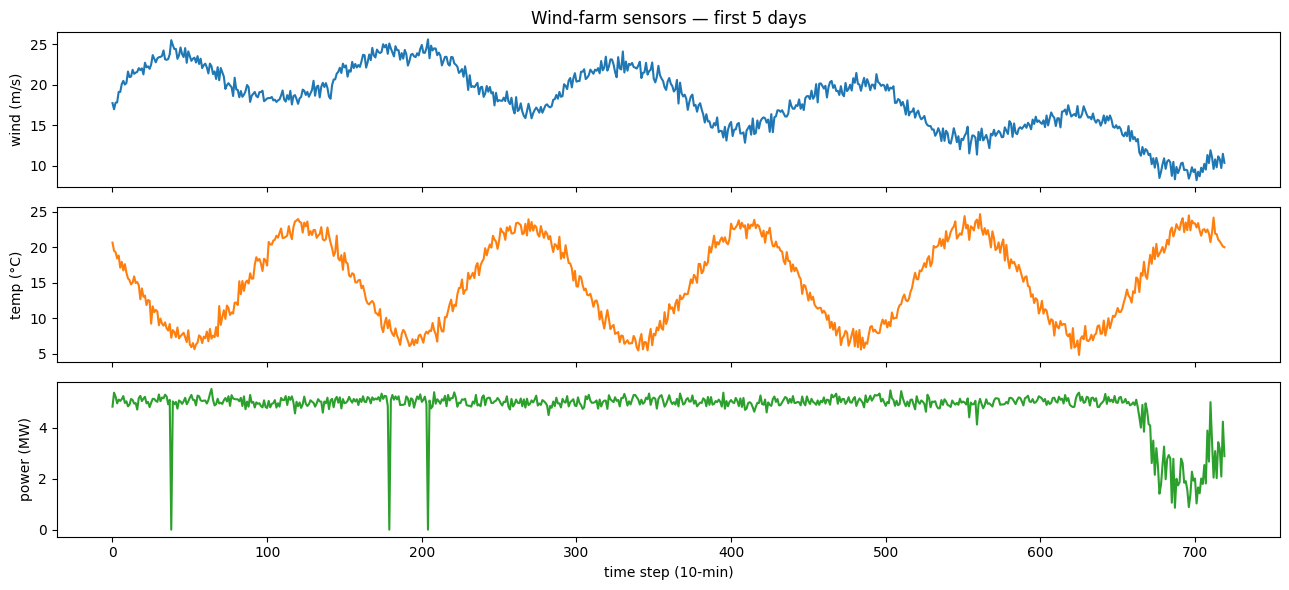

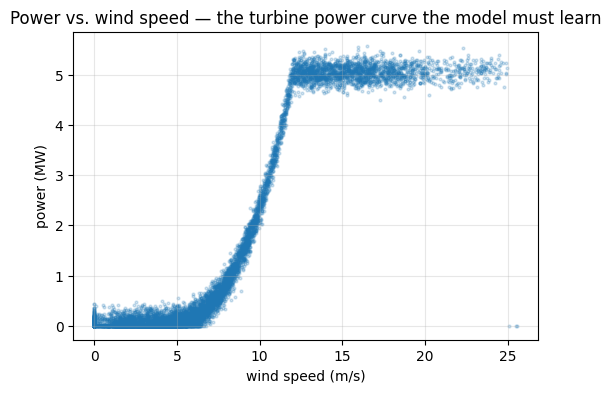

In [4]:
# visualize a few days, and the discovered power curve
fig, axes = plt.subplots(3, 1, figsize=(13, 6), sharex=True)
show = slice(0, STEPS_PER_DAY * 5)   # first 5 days
axes[0].plot(t[show], wind_speed[show], color="#1f77b4"); axes[0].set_ylabel("wind (m/s)")
axes[1].plot(t[show], ambient_temp[show], color="#ff7f0e"); axes[1].set_ylabel("temp (°C)")
axes[2].plot(t[show], power[show], color="#2ca02c"); axes[2].set_ylabel("power (MW)")
axes[2].set_xlabel("time step (10-min)")
axes[0].set_title("Wind-farm sensors — first 5 days"); plt.tight_layout(); plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(wind_speed, power, s=4, alpha=0.2)
plt.title("Power vs. wind speed — the turbine power curve the model must learn")
plt.xlabel("wind speed (m/s)"); plt.ylabel("power (MW)"); plt.grid(alpha=0.3); plt.show()

## 2. Frame the forecasting problem: sliding windows for multi-step output

- **Inputs (encoder)** — the past `PAST=72` steps (12 h) of **5 features**:
  `[power, wind_speed, ambient_temp, hour_sin, hour_cos]`. We include past power because it's
  highly autocorrelated, and cyclic **hour-of-day** encoding so the model knows the time.
- **Target** — the next `HORIZON=18` steps (3 h) of **power**.

So each training example is `X: (72, 5)` → `y: (18,)`. We also keep, for each example, the **last
known power** value (the decoder's starting point) and the **origin index** (to compute the
seasonal-naive baseline from the full history).

In [5]:
PAST, HORIZON = 72, 18   # 12h history -> 3h ahead (72*10min = 12h, 18*10min = 3h)

# cyclic encoding of time-of-day (so 23:50 and 00:00 are "close")
hour_sin = np.sin(2 * np.pi * day_frac)
hour_cos = np.cos(2 * np.pi * day_frac)

# feature matrix (N, 5); target is the power column
features = np.stack([power, wind_speed, ambient_temp, hour_sin, hour_cos], axis=1).astype(np.float32)
target = power.astype(np.float32)
FEATURE_NAMES = ["power", "wind_speed", "ambient_temp", "hour_sin", "hour_cos"]

def make_windows(features, target, past, horizon):
    X, y, prev, origin = [], [], [], []
    for i in range(len(features) - past - horizon):
        o = i + past                      # forecast origin (first step to predict is `o`)
        X.append(features[i:o])           # (n_samples, past_length, n_features)
        y.append(target[o:o + horizon])   # (n_samples, horizon_length)
        prev.append(target[o - 1])        # last KNOWN power, decoder seed (n_samples,)
        origin.append(o)
    return (np.array(X), np.array(y, dtype=np.float32),
            np.array(prev, dtype=np.float32), np.array(origin))

X, y, prev, origin = make_windows(features, target, PAST, HORIZON)
print("X:", X.shape, "| y:", y.shape, "| prev:", prev.shape)

X: (8550, 72, 5) | y: (8550, 18) | prev: (8550,)


In [6]:
X[0, :, 0] # this is the power sample from t=0 to t=71 (the first 12h of the first day)
X[0, :, 1] # this is the wind_speed sample from t=0 to t=71 (the first 12h of the first day)
X[1, :, 0] # this is the power sample from t=1 to t=72
y[0, :] # this is the power sample from t=72 to t=89 (the first 3h of the first day)
prev[0] == X[0, -1, 0] # this should be the same as prev[0] (the last known power at t=71)

np.True_

In [7]:
# time-based split: 70% train, 15% val, 15% test — NEVER shuffle before splitting a time series
n = len(X); a, b = int(0.7 * n), int(0.85 * n)
slices = {"train": slice(0, a), "val": slice(a, b), "test": slice(b, n)}

# scale features & target using TRAIN statistics only (avoid look-ahead leakage)
f_mean = X[slices["train"]].reshape(-1, X.shape[2]).mean(0)
f_std  = X[slices["train"]].reshape(-1, X.shape[2]).std(0)
# target (power) is feature index 0 -> reuse its stats so encoder & decoder share the same scale
p_mean, p_std = f_mean[0], f_std[0]

def scale_X(a): return ((a - f_mean) / f_std).astype(np.float32) # scale X features
def scale_p(a): return ((a - p_mean) / p_std).astype(np.float32) # scale power target
def unscale_p(a): return a * p_std + p_mean          # back to MW for reporting

def to_loader(part, batch=128, shuffle=False):
    Xs = torch.tensor(scale_X(X[slices[part]])) # X scaled
    ys = torch.tensor(scale_p(y[slices[part]])) # y scaled
    ps = torch.tensor(scale_p(prev[slices[part]])).unsqueeze(1)   # previous power scaled
    ds = TensorDataset(Xs, ps, ys) 
    return DataLoader(ds, batch_size=batch, shuffle=shuffle)

train_loader = to_loader("train", shuffle=True)
val_loader   = to_loader("val")
test_loader  = to_loader("test")
print("batches:", len(train_loader), "| example batch shapes:",
      [tuple(t.shape) for t in next(iter(train_loader))])

batches: 47 | example batch shapes: [(128, 72, 5), (128, 1), (128, 18)]


## 3. Model A — Direct multi-output GRU (simple & strong)

The simplest way to predict `HORIZON` steps at once: encode the past window with a GRU, take the
**final hidden state** (the summary of the whole window), and map it with a linear layer to all
`18` future values **in one shot**.

- ✅ Pros: simple, fast, no compounding errors (every horizon step predicted independently).
- ⚠️ Cons: ignores the sequential structure *among* the outputs; the head must learn all steps
  jointly.

### The scheme — one summary, one Linear, all steps at once

The **Direct** model is the simplest way to turn a window into a multi-step forecast:

1. a **GRU encoder** reads the whole past window and boils it down to its **final hidden state** — a
   single vector summarizing the last 12 hours (exactly the same "encoder" idea as in Model B);
2. a **single `Linear` layer** maps that one summary vector straight to **all 18 future values at
   once**.

There is **no decoder and no feedback loop** — every future step is read off the *same* summary in a
single shot. That makes it simple, fast, and free of compounding errors. Compare the scheme below
with the encoder–decoder in Section 4: same encoder, but the *output* half is one `Linear` instead
of a step-by-step decoder.

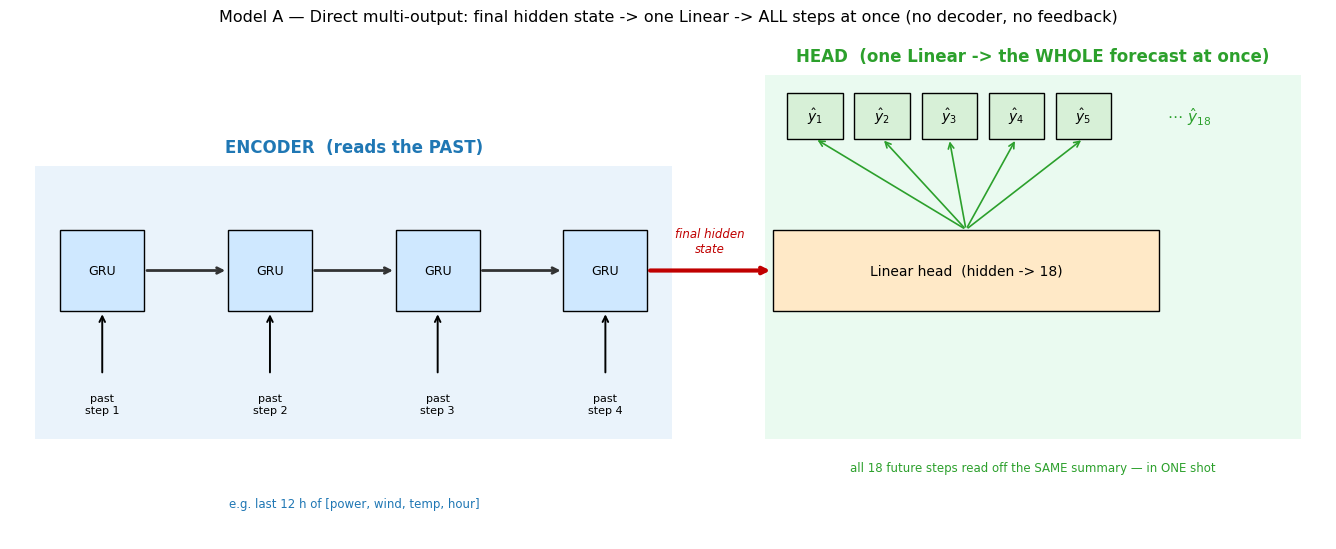

In [8]:
# A scheme of Model A (the Direct multi-output GRU) we build below.
from matplotlib.patches import Rectangle

def draw_direct():
    n_enc = 4
    xs, yc = 2.0, 1.8
    fig, ax = plt.subplots(figsize=(13.5, 5.6))

    encL, encR = 1 - 0.8, (n_enc - 1) * xs + 1 + 0.8
    ax.add_patch(Rectangle((encL, 0.4), encR - encL, 3.0, color="#eaf3fb", ec="none", zorder=0))
    ax.add_patch(Rectangle((8.9, 0.4), 6.4, 4.0, color="#eafaf0", ec="none", zorder=0))
    ax.text((encL + encR) / 2, 3.55, "ENCODER  (reads the PAST)", ha="center", color="#1f77b4",
            fontsize=12, weight="bold")
    ax.text(12.1, 4.55, "HEAD  (one Linear -> the WHOLE forecast at once)", ha="center",
            color="#2ca02c", fontsize=12, weight="bold")

    for t in range(n_enc):                              # encoder GRU cells
        x = t * xs + 1
        ax.add_patch(Rectangle((x - 0.5, yc), 1.0, 0.9, color="#cfe8ff", ec="black", zorder=2))
        ax.text(x, yc + 0.45, "GRU", ha="center", va="center", fontsize=9, zorder=3)
        if t < n_enc - 1:
            ax.annotate("", xy=(x + xs - 0.5, yc + 0.45), xytext=(x + 0.5, yc + 0.45),
                        arrowprops=dict(arrowstyle="->", lw=2, color="#333", zorder=2))
        ax.annotate("", xy=(x, yc), xytext=(x, yc - 0.7), arrowprops=dict(arrowstyle="->", lw=1.4))
        ax.text(x, yc - 0.9, f"past\nstep {t+1}", ha="center", va="top", fontsize=8)

    xlast = (n_enc - 1) * xs + 1                        # final hidden state -> Linear head
    ax.annotate("", xy=(9.0, yc + 0.45), xytext=(xlast + 0.5, yc + 0.45),
                arrowprops=dict(arrowstyle="->", lw=3, color="#c00000", zorder=4))
    ax.text((xlast + 0.5 + 9.0) / 2, yc + 0.62, "final hidden\nstate", ha="center", va="bottom",
            fontsize=8.5, color="#c00000", style="italic")
    ax.add_patch(Rectangle((9.0, yc), 4.6, 0.9, color="#ffe9c7", ec="black", zorder=2))
    ax.text(11.3, yc + 0.45, "Linear head  (hidden -> 18)", ha="center", va="center", fontsize=10, zorder=3)

    outs_x = [9.5, 10.3, 11.1, 11.9, 12.7]              # fan out to ALL outputs at once
    for i, ox in enumerate(outs_x):
        ax.add_patch(Rectangle((ox - 0.33, 3.7), 0.66, 0.5, color="#d7f0d7", ec="black", zorder=2))
        ax.text(ox, 3.95, f"$\\hat{{y}}_{i+1}$", ha="center", va="center", fontsize=10, zorder=3)
        ax.annotate("", xy=(ox, 3.7), xytext=(11.3, yc + 0.9),
                    arrowprops=dict(arrowstyle="->", lw=1.2, color="#2ca02c", zorder=1))
    ax.text(13.7, 3.95, r"$\cdots\ \hat{y}_{18}$", ha="left", va="center", fontsize=11, color="#2ca02c")

    ax.text((encL + encR) / 2, -0.35, "e.g. last 12 h of [power, wind, temp, hour]",
            ha="center", fontsize=8.5, color="#1f77b4")
    ax.text(12.1, 0.05, "all 18 future steps read off the SAME summary — in ONE shot",
            ha="center", fontsize=8.5, color="#2ca02c")
    ax.set_xlim(encL - 0.3, 15.6); ax.set_ylim(-0.7, 4.9); ax.axis("off")
    ax.set_title("Model A — Direct multi-output: final hidden state -> one Linear -> ALL steps at once "
                 "(no decoder, no feedback)", fontsize=11.5)
    plt.tight_layout(); plt.show()

draw_direct()

In [9]:
class DirectForecaster(nn.Module):
    def __init__(self, n_features=5, hidden=64, horizon=HORIZON, n_layers=2):
        super().__init__()
        self.gru = nn.GRU(n_features, hidden, num_layers=n_layers, batch_first=True, dropout=0.1)
        self.head = nn.Linear(hidden, horizon)     # final memory -> all horizon steps at once

    def forward(self, x, prev=None):
        h_out, _ = self.gru(x)
        return self.head(h_out[:, -1, :])            # (batch, horizon)

print(DirectForecaster())

DirectForecaster(
  (gru): GRU(5, 64, num_layers=2, batch_first=True, dropout=0.1)
  (head): Linear(in_features=64, out_features=18, bias=True)
)


## 4. Model B — Encoder–Decoder (seq2seq) with teacher forcing

The classic **many-to-many** architecture, and the template behind machine translation:

- **Encoder** GRU reads the past window and compresses it into a **context** (its final hidden
  state).
- **Decoder** GRU **generates the horizon one step at a time**, initialized with that context. At
  each step it takes the *previous power value* and predicts the next one — autoregression, just
  like the text generator in notebook 05, but for numbers.

**Teacher forcing** (training trick): with some probability we feed the decoder the *true*
previous value instead of its own prediction. This stabilizes early training. At inference we must
feed its **own** predictions (the true future is unknown), so errors can compound — the classic
seq2seq trade-off.

### What is an encoder–decoder, and why use it here?

The short paragraph above packs a lot in — let's slow right down and *see* it, assuming you're fairly
new to RNNs.

Our goal is to predict the **next 3 hours** (18 steps) of power from the **last 12 hours** (72 steps)
of sensor readings. That's a **sequence in → sequence out** problem: many inputs → many outputs, and
the two sequences even have **different lengths** (72 in, 18 out). The standard tool for this is the
**encoder–decoder**, also called **seq2seq** ("sequence to sequence") — the very same design behind
machine translation (a sentence in one language → a sentence in another).

**A human analogy.** Picture a plant operator who:

1. **reads** the last 12 hours of gauges and forms a mental picture of *"what the wind and the plant
   are doing right now"* — that mental summary is the **context**;
2. then **writes down** the forecast for the coming hours **one number at a time**, each new number
   informed by the one they just wrote.

Step 1 is the **encoder**. Step 2 is the **decoder**. The scheme below shows exactly this — read it
top-to-bottom with the text that follows.

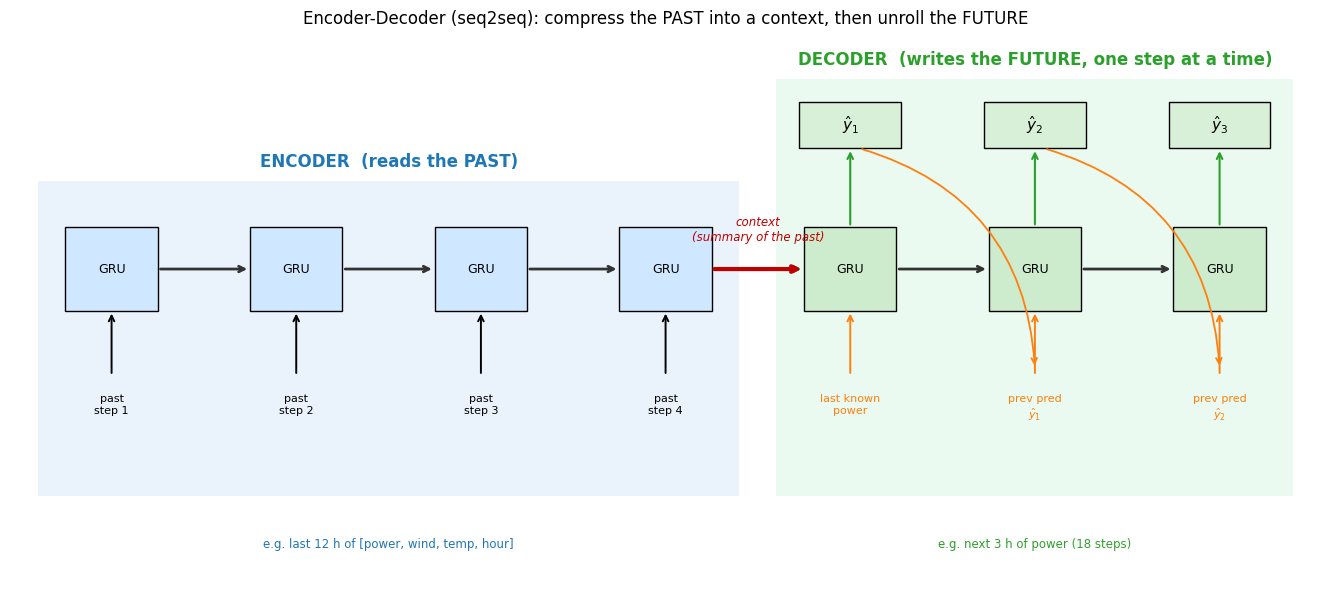

In [10]:
# A scheme of the encoder-decoder (seq2seq) we build below.
from matplotlib.patches import Rectangle

def draw_seq2seq():
    n_enc, n_dec = 4, 3
    xs, yc = 2.0, 2.2
    fig, ax = plt.subplots(figsize=(13.5, 6.0))

    encL, encR = 1 - 0.8, (n_enc - 1) * xs + 1 + 0.8
    decL, decR = n_enc * xs + 1 - 0.8, (n_enc + n_dec - 1) * xs + 1 + 0.8
    ax.add_patch(Rectangle((encL, 0.2), encR - encL, 3.4, color="#eaf3fb", ec="none", zorder=0))
    ax.add_patch(Rectangle((decL, 0.2), decR - decL, 4.5, color="#eafaf0", ec="none", zorder=0))
    ax.text((encL + encR) / 2, 3.75, "ENCODER  (reads the PAST)", ha="center", color="#1f77b4",
            fontsize=12, weight="bold")
    ax.text((decL + decR) / 2, 4.85, "DECODER  (writes the FUTURE, one step at a time)",
            ha="center", color="#2ca02c", fontsize=12, weight="bold")

    for t in range(n_enc + n_dec):
        x = t * xs + 1
        is_enc = t < n_enc
        ax.add_patch(Rectangle((x - 0.5, yc), 1.0, 0.9, color="#cfe8ff" if is_enc else "#cdeccd",
                               ec="black", zorder=2))
        ax.text(x, yc + 0.45, "GRU", ha="center", va="center", fontsize=9, zorder=3)
        if t < n_enc + n_dec - 1:                       # hidden-state arrow to the next cell
            ax.annotate("", xy=(x + xs - 0.5, yc + 0.45), xytext=(x + 0.5, yc + 0.45),
                        arrowprops=dict(arrowstyle="->", lw=2, color="#333", zorder=2))
        if is_enc:
            ax.annotate("", xy=(x, yc), xytext=(x, yc - 0.7), arrowprops=dict(arrowstyle="->", lw=1.4))
            ax.text(x, yc - 0.9, f"past\nstep {t+1}", ha="center", va="top", fontsize=8)
        else:
            d = t - n_enc
            ax.annotate("", xy=(x, yc + 1.75), xytext=(x, yc + 0.9),
                        arrowprops=dict(arrowstyle="->", lw=1.5, color="#2ca02c"))
            ax.add_patch(Rectangle((x - 0.55, yc + 1.75), 1.1, 0.5, color="#d7f0d7", ec="black", zorder=2))
            ax.text(x, yc + 2.0, f"$\\hat{{y}}_{d+1}$", ha="center", va="center", fontsize=11, zorder=3)
            ax.annotate("", xy=(x, yc), xytext=(x, yc - 0.7),
                        arrowprops=dict(arrowstyle="->", lw=1.4, color="#ff7f0e"))
            ax.text(x, yc - 0.9, ("last known\npower" if d == 0 else f"prev pred\n$\\hat{{y}}_{d}$"),
                    ha="center", va="top", fontsize=8, color="#ff7f0e")
            if d < n_dec - 1:                            # feed the prediction back as the next input
                ax.annotate("", xy=(x + xs, yc - 0.62), xytext=(x + 0.1, yc + 1.75),
                            arrowprops=dict(arrowstyle="->", lw=1.3, color="#ff7f0e",
                                            connectionstyle="arc3,rad=-0.35"))

    xb = (n_enc - 1) * xs + 1                            # the boundary hidden arrow IS the context
    ax.text(xb + xs / 2, yc + 0.72, "context\n(summary of the past)", ha="center", va="bottom",
            fontsize=8.5, color="#c00000", style="italic")
    ax.annotate("", xy=(xb + xs - 0.5, yc + 0.45), xytext=(xb + 0.5, yc + 0.45),
                arrowprops=dict(arrowstyle="->", lw=3, color="#c00000", zorder=4))
    ax.text((encL + encR) / 2, -0.35, "e.g. last 12 h of [power, wind, temp, hour]",
            ha="center", fontsize=8.5, color="#1f77b4")
    ax.text((decL + decR) / 2, -0.35, "e.g. next 3 h of power (18 steps)",
            ha="center", fontsize=8.5, color="#2ca02c")
    ax.set_xlim(encL - 0.3, decR + 0.3); ax.set_ylim(-0.7, 5.2); ax.axis("off")
    ax.set_title("Encoder-Decoder (seq2seq): compress the PAST into a context, then unroll the FUTURE",
                 fontsize=12)
    plt.tight_layout(); plt.show()

draw_seq2seq()

### The two halves, step by step

Recall the one idea behind every RNN (notebook 01): it walks through a sequence one step at a time,
carrying a **hidden state** — a small vector of numbers that is its **memory** of everything seen so
far.

**🔵 The ENCODER** is an RNN (a GRU here) that reads the **past window**. At each of the 72 steps it
takes that step's readings `[power, wind, temp, hour]` and updates its hidden state. We **throw away
the per-step outputs** and keep only the **final hidden state** — that single vector is the
**context**: a compressed summary of the entire 12-hour history (*"windy and rising, evening,
cooling down"*). It's the encoder's answer to *"in one snapshot, what is the situation right now?"*

**🟢 The DECODER** is a *second, separate* RNN that **generates the forecast one step at a time**:

- it **starts** from the context (the encoder's summary becomes the decoder's initial memory);
- its **first input** is the **last known power** value;
- it outputs a prediction $\hat{y}_1$ for the next step;
- that prediction is **fed back in** as the input for the following step → it outputs $\hat{y}_2$, and
  so on for all 18 steps.

That "use my own last output as the next input" loop is called **autoregression** — the same idea as
the character generator in notebook 05, but predicting numbers instead of letters.

**Teacher forcing (a training-only trick).** Feeding the decoder its *own* predictions during
**training** can be unstable early on — one bad early guess snowballs into the rest. So during
training we sometimes feed the **true** previous value instead of the predicted one; that is
**teacher forcing**. At **inference** we cannot do this (the future is unknown!), so the decoder must
run on its own predictions — which is exactly why forecast error tends to **grow the further ahead**
we look (you'll see this in Section 7).

### Why bother? Encoder–decoder vs. the "Direct" model

Model A (the **Direct GRU** above) predicts all 18 future values **in one shot** from the encoder's
summary. The encoder–decoder instead builds the forecast **step by step**. The trade-offs:

| | **Direct** (Model A) | **Encoder–Decoder** (Model B) |
|---|---|---|
| how it outputs | all 18 steps at once (one `Linear`) | one step at a time, autoregressively |
| models order *between* outputs? | no — each step predicted independently | **yes** — each step is conditioned on the previous one |
| errors compounding | none | possible (its own mistakes feed forward) |
| flexibility | fixed horizon | any horizon; can also take **known future inputs** (e.g. a wind forecast) at each decoder step |
| complexity | simple, robust, fast | more expressive, more moving parts |

**When the encoder–decoder shines:** long or variable horizons, when future steps genuinely depend on
one another, or when you have **known future covariates** to feed the decoder (say, a weather forecast
for the coming hours). It's also the stepping-stone to **attention** and Transformers. For our short
3-hour horizon the simpler Direct model is often just as good — which is *precisely* why we build and
compare **both**.

Now let's read the implementation. 👇

In [ ]:
class Seq2SeqForecaster(nn.Module):
    def __init__(self, n_features=5, hidden=64, n_layers=2):
        super().__init__()
        self.encoder = nn.GRU(n_features, hidden, num_layers=n_layers, batch_first=True, dropout=0.1)
        self.dec_cell = nn.GRUCell(input_size=1, hidden_size=hidden)      # decoder input = previous power (1 number)
        self.dec_head = nn.Linear(hidden, 1)       # hidden -> next power
        self.hidden = hidden

    def forward(self, x, prev, targets=None, teacher_forcing=0.5, horizon=HORIZON):
        # encode the past window
        _, h_last = self.encoder(x)                     # h: (n_layers, batch, hidden)
        h_dec = h_last[-1]                              # use the top layer's final state as context, since the top layer is the most abstract representation of the past
        inp = prev                                 # (batch, 1) last KNOWN power = decoder seed
        outputs = []
        for step in range(horizon):
            h_dec = self.dec_cell(inp, h_dec)      # advance decoder one step
            pred = self.dec_head(h_dec)            # (batch, 1) next power
            outputs.append(pred)
            # decide next input: true value (teacher forcing) or our own prediction
            if self.training and targets is not None and torch.rand(1).item() < teacher_forcing:
                inp = targets[:, step:step + 1]
            else:
                inp = pred                         # autoregress on our own output
        return torch.cat(outputs, dim=1)           # (batch, horizon)

print(Seq2SeqForecaster())

Seq2SeqForecaster(
  (encoder): GRU(5, 64, num_layers=2, batch_first=True, dropout=0.1)
  (dec_cell): GRUCell(1, 64)
  (dec_head): Linear(in_features=64, out_features=1, bias=True)
)


## 5. Train both models with the same loop

We reuse one training function. Note the seq2seq model needs the targets passed in during training
(for teacher forcing), so the loop handles both signatures.

In [12]:
def run_epoch(model, loader, opt=None):
    training = opt is not None
    model.train() if training else model.eval()
    loss_fn = nn.MSELoss()
    total, count = 0.0, 0
    torch.set_grad_enabled(training)
    for xb, pb, yb in loader:
        xb, pb, yb = xb.to(device), pb.to(device), yb.to(device)
        if isinstance(model, Seq2SeqForecaster):
            pred = model(xb, pb, targets=yb, teacher_forcing=0.5 if training else 0.0)
        else:
            pred = model(xb, pb)
        loss = loss_fn(pred, yb)
        if training:
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # guard against exploding grads
            opt.step()
        total += loss.item() * len(yb); count += len(yb)
    torch.set_grad_enabled(True)
    return total / count

def train_model(model, epochs=25, lr=2e-3):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {"train": [], "val": []}
    for ep in range(epochs):
        tr = run_epoch(model, train_loader, opt)
        va = run_epoch(model, val_loader)
        hist["train"].append(tr); hist["val"].append(va)
        if (ep + 1) % 5 == 0:
            print(f"  epoch {ep+1:2d} | train MSE {tr:.4f} | val MSE {va:.4f}")
    return hist

print("Training Model A — Direct multi-output GRU:")
direct = DirectForecaster()
h_direct = train_model(direct)

print("\nTraining Model B — Encoder–Decoder seq2seq GRU:")
seq2seq = Seq2SeqForecaster()
h_seq2seq = train_model(seq2seq)

Training Model A — Direct multi-output GRU:
  epoch  5 | train MSE 0.0344 | val MSE 0.0354
  epoch 10 | train MSE 0.0326 | val MSE 0.0325
  epoch 15 | train MSE 0.0318 | val MSE 0.0329
  epoch 20 | train MSE 0.0305 | val MSE 0.0340
  epoch 25 | train MSE 0.0300 | val MSE 0.0350

Training Model B — Encoder–Decoder seq2seq GRU:
  epoch  5 | train MSE 0.0296 | val MSE 0.0355
  epoch 10 | train MSE 0.0284 | val MSE 0.0369
  epoch 15 | train MSE 0.0280 | val MSE 0.0336
  epoch 20 | train MSE 0.0274 | val MSE 0.0350
  epoch 25 | train MSE 0.0269 | val MSE 0.0375


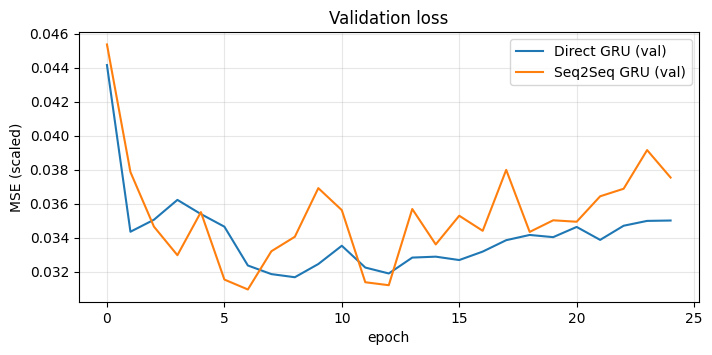

In [13]:
plt.figure(figsize=(8, 3.5))
plt.plot(h_direct["val"], label="Direct GRU (val)")
plt.plot(h_seq2seq["val"], label="Seq2Seq GRU (val)")
plt.title("Validation loss"); plt.xlabel("epoch"); plt.ylabel("MSE (scaled)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 6. Baselines a client will demand

Never present a fancy model without comparing to trivial baselines — sometimes they're
surprisingly hard to beat, and beating them is what proves your model earns its complexity.

- **Persistence ("it stays the same"):** predict the last known power for all 18 future steps.
- **Seasonal naive ("same as yesterday"):** predict the power from exactly **one day ago**
  (`144` steps back) at each future step — captures the daily cycle for free.

We compute all predictions on the **test set** in real units (MW) and compare.

In [15]:
@torch.no_grad()
def predict(model, loader):
    model.eval()
    preds = []
    for xb, pb, yb in loader:
        xb, pb = xb.to(device), pb.to(device)
        preds.append(model(xb, pb).cpu().numpy())
    return unscale_p(np.concatenate(preds))       # back to MW

# model predictions (MW)
pred_direct  = predict(direct, test_loader)
pred_seq2seq = predict(seq2seq, test_loader)

# ground truth (MW) for the test slice
y_test = y[slices["test"]]                              # already in MW

# baselines (MW), using stored origin indices into the full series
test_origin = origin[slices["test"]]
pred_persist = np.repeat(prev[slices["test"]][:, None], HORIZON, axis=1)      # last value held flat
pred_seasonal = np.stack([
    target[o - STEPS_PER_DAY : o - STEPS_PER_DAY + HORIZON] for o in test_origin
])                                                                        # 1 day ago

def mae(a, b):  return float(np.mean(np.abs(a - b)))
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))

print("Test-set forecast error (MW), averaged over all horizons:\n")
print(f"{'model':<22}{'MAE':>8}{'RMSE':>8}")
for name, p in [("Persistence", pred_persist), ("Seasonal naive", pred_seasonal),
                ("Direct GRU", pred_direct), ("Seq2Seq GRU", pred_seq2seq)]:
    print(f"{name:<22}{mae(p, y_test):>8.3f}{rmse(p, y_test):>8.3f}")
print("\nLower is better. The GRUs should clearly beat persistence and seasonal-naive.")

Test-set forecast error (MW), averaged over all horizons:

model                      MAE    RMSE
Persistence              0.145   0.240
Seasonal naive           0.190   0.317
Direct GRU               0.119   0.179
Seq2Seq GRU              0.125   0.180

Lower is better. The GRUs should clearly beat persistence and seasonal-naive.


## 7. Error vs. horizon — the further out, the harder

A single average hides a crucial fact: **forecasts get worse the further ahead you look.** Plotting
error per horizon step is what lets you tell a client *"we're reliable for ~1 hour, degrading
after that."* It also reveals whether seq2seq's compounding hurts at longer horizons.

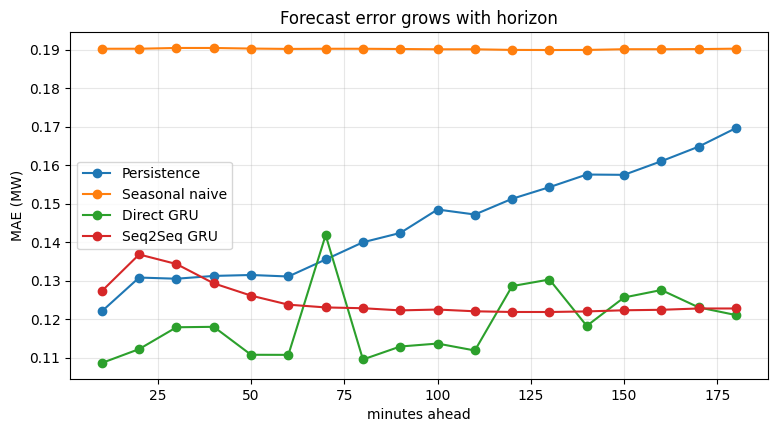

In [16]:
def mae_per_step(pred): return np.mean(np.abs(pred - y_test), axis=0)   # (HORIZON,)

steps_ahead = (np.arange(HORIZON) + 1) * 10   # minutes ahead
plt.figure(figsize=(9, 4.5))
for name, p in [("Persistence", pred_persist), ("Seasonal naive", pred_seasonal),
                ("Direct GRU", pred_direct), ("Seq2Seq GRU", pred_seq2seq)]:
    plt.plot(steps_ahead, mae_per_step(p), marker="o", label=name)
plt.title("Forecast error grows with horizon")
plt.xlabel("minutes ahead"); plt.ylabel("MAE (MW)"); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 8. Look at actual forecasts

Numbers are abstract — let's overlay a few example 3-hour forecasts on the truth. We show the
recent history, then the model forecast vs. what actually happened.

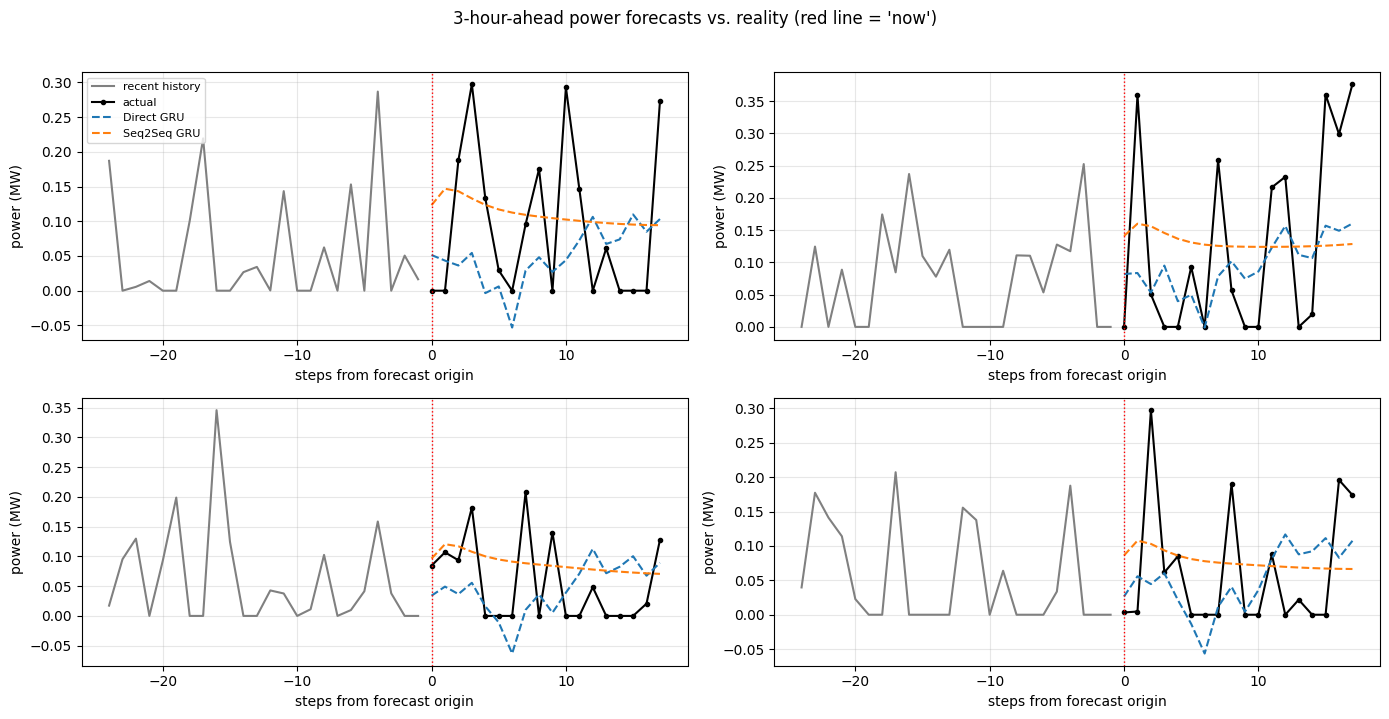

In [ ]:
test_start = sl["test"].start
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
examples = np.linspace(0, len(y_test) - 1, 4).astype(int)
for ax, idx in zip(axes.ravel(), examples):
    o = origin[test_start + idx]
    hist_x = np.arange(-24, 0)                     # last 4 hours of context
    fut_x  = np.arange(0, HORIZON)
    ax.plot(hist_x, target[o - 24:o], color="gray", label="recent history")
    ax.plot(fut_x, y_test[idx], "k-o", ms=3, label="actual")
    ax.plot(fut_x, pred_direct[idx], "--", label="Direct GRU")
    ax.plot(fut_x, pred_seq2seq[idx], "--", label="Seq2Seq GRU")
    ax.axvline(0, color="red", ls=":", lw=1)
    ax.set_xlabel("steps from forecast origin"); ax.set_ylabel("power (MW)")
    ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=8)
plt.suptitle("3-hour-ahead power forecasts vs. reality (red line = 'now')", y=1.02)
plt.tight_layout(); plt.show()

## 9. From forecast to business value — the consultant's layer

A working model is the *middle* of the engagement, not the end. What turns it into value:

**Uncertainty, not just a point estimate.** The grid operator needs a *range*. Train with a
**quantile (pinball) loss** to predict, say, the 10th/50th/90th percentiles, giving a
probabilistic band. "5 MW ± 1.5" is far more actionable than "5 MW".

**Predictive maintenance tie-in.** The *residual* (actual − predicted) is a powerful health
signal: if a turbine persistently underperforms its wind-implied forecast, that's an early warning
of blade soiling, yaw misalignment, or a failing gearbox — connecting back to notebook 04's
fault-classification work.

**Deployment realities:**
- **Latency & streaming** — forecasts must be produced within the 10-min cadence; GRU/LSTM are
  cheap and stream naturally (fixed cost per step), a reason RNNs remain favored over Transformers
  for real-time sensor pipelines.
- **Retraining & drift** — seasons, turbine aging, and sensor recalibration shift the data; monitor
  error and retrain on a schedule.
- **Multi-turbine / hierarchical** — forecast each turbine and reconcile to the farm total; spatial
  correlations between turbines can be added as extra features.
- **Exogenous inputs** — a numerical **weather forecast** for future wind is the single biggest
  accuracy lever; feed it into the decoder as *known future covariates*.

**Which model to ship?** Start with the **Direct GRU** — simpler, robust, no compounding error,
and here it's typically as good or better at these horizons. Reach for **seq2seq** when you need
per-step generation, known future covariates in the decoder, or attention over the input.

## 10. Series recap — what you can now do

Across the six notebooks you've gone from zero to a deployable-shaped forecasting system:

| Notebook | You learned |
|---|---|
| 01 Fundamentals | hidden state = memory, the recurrence, unrolling/flow, the 5 shapes, a from-scratch cell |
| 02 First PyTorch RNN | tensor shapes, `nn.RNNCell` vs `nn.RNN`, the training loop, time-split, naive baseline |
| 03 LSTM & GRU | vanishing gradients, gates, and *proof* LSTM/GRU beat RNN on long memory |
| 04 Many-to-one | multivariate classification, `DataLoader`, confusion-matrix evaluation |
| 05 One-to-many | autoregressive generation, embeddings, temperature sampling |
| 06 Capstone | multivariate seq2seq forecasting, baselines, error-vs-horizon, business framing |

**Where to go next:** add **attention** to the seq2seq decoder; try **Temporal Fusion
Transformers** or **N-BEATS/N-HiTS** for forecasting; explore libraries like **Darts**,
**GluonTS**, or **PyTorch Forecasting** that package these patterns. But the intuition you built
here — *memory flowing through time, gated to persist, shaped to the problem* — is what makes all
of them make sense.

🎉 **Congratulations — you've completed the RNN series!**